# 08 - XAI Visualizations (Grad-CAM++, LIME, SHAP)

Explainability analysis: Grad-CAM++ heatmaps, LIME superpixel explanations, SHAP image plots, occlusion tests, intensity proof, attention ratio/contrast ratio. True Positive and True Negative cases visualized.

In [13]:
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, x, class_idx):
        self.model.zero_grad()
        output = self.model(x)
        score = output[:, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        alpha_num = grads.pow(2)
        alpha_denom = 2 * grads.pow(2) + \
                      (acts * grads.pow(3)).sum(dim=(2, 3), keepdim=True)
        alpha = alpha_num / (alpha_denom + 1e-7)

        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-7)

        return cam


In [14]:
target_layer = model.backbone.features[-1]
cam_extractor = GradCAMPlusPlus(model, target_layer)


In [18]:

# ===================== LOAD VALIDATION DATA =====================
val_data = np.load("val_data.npy")
val_label = np.load("val_label.npy")

# NHWC -> NCHW if needed
if val_data.ndim == 4 and val_data.shape[-1] == 3:
    val_data = val_data.transpose(0, 3, 1, 2)

x = torch.tensor(val_data, dtype=torch.float32)
y = torch.tensor(val_label, dtype=torch.long)

# Scale if in [0,255]
if x.max() > 2.0:
    x = x / 255.0

# Resize & Normalize (ImageNet)
x = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
x = (x - mean) / std

x = x.to(device)
y = y.to(device)


In [20]:
idx = 20
img = x[idx].unsqueeze(0).to(device)   # <-- THIS LINE FIXES IT
img = img.to(device)
model.to(device)
model.eval()


ConvNeXtLargeCustom(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((192,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
            (1): Permute()
            (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=192, out_features=768, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=768, out_features=192, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
            (1): Permute()
            

In [21]:

output = model(img)
prob = torch.softmax(output, dim=1)[0, 1].item()
pred = torch.argmax(output, dim=1).item()

cam = cam_extractor.generate(img, pred)

cam = F.interpolate(
    cam.unsqueeze(1),
    size=(256, 256),
    mode="bilinear",
    align_corners=False
).squeeze().detach().cpu().numpy()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [19]:
mean_vis = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_vis  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# Remove batch dimension safely
img_vis = img.detach().cpu()[0]   # (3, H, W)

# De-normalize (NO batch re-added)
img_vis = img_vis * std_vis + mean_vis

# CHW → HWC
img_vis = img_vis.permute(1, 2, 0).numpy()

# Clip for display
img_vis = np.clip(img_vis, 0, 1)



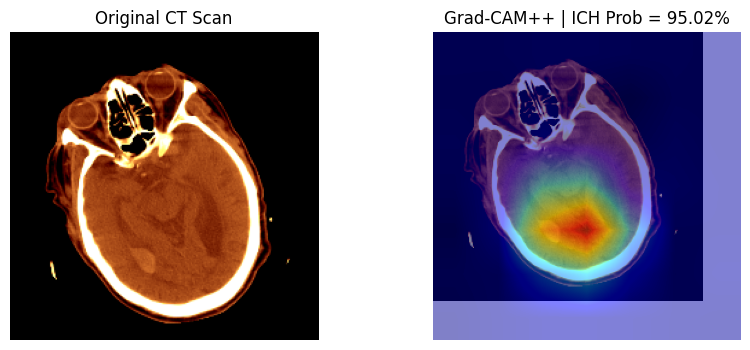

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_vis)
plt.title("Original CT Scan")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_vis)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM++ | ICH Prob = {prob*100:.2f}%")
plt.axis("off")

plt.show()


In [26]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

os.makedirs("xai_results/true_positive", exist_ok=True)

# ===================== LOAD DATA =====================
val_data = np.load("val_data.npy")
val_label = np.load("val_label.npy")

x = torch.tensor(val_data, dtype=torch.float32)
y = torch.tensor(val_label, dtype=torch.long)

# 👉 FIX 1: ensure NCHW
if x.ndim == 4 and x.shape[-1] == 3:
    x = x.permute(0, 3, 1, 2)   # NHWC → NCHW

# 👉 FIX 2: scale if needed
if x.max() > 2.0:
    x = x / 255.0

# ImageNet normalization (same as training)
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
x = (x - mean) / std

# For visualization (NO batch dim)
mean_vis = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_vis  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

# ===================== TRUE POSITIVE LOOP =====================
for i in range(len(x)):
    img = x[0].unsqueeze(0).to(device)   # (1,3,H,W)
    label = y[i].item()

    output = model(img)
    prob = torch.softmax(output, dim=1)[0,1].item()
    pred = torch.argmax(output, dim=1).item()

    # TRUE POSITIVE: predicted ICH & actually ICH
    if pred == 1 and label == 1:

        cam = cam_extractor.generate(img, pred)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(256,256),
            mode="bilinear",
            align_corners=False
        ).squeeze().detach().cpu().numpy()

        # 👉 FIX 3: proper de-normalization for display
        img_vis = img.detach().cpu()[0]      # (3,H,W)
        img_vis = img_vis * std_vis + mean_vis
        img_vis = img_vis.permute(1,2,0).numpy()
        img_vis = np.clip(img_vis, 0, 1)

        # ===================== PLOT =====================
        plt.figure(figsize=(6,3))

        plt.subplot(1,2,1)
        plt.imshow(img_vis)
        plt.title("ICH CT Scan")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(img_vis)
        plt.imshow(cam, cmap="jet", alpha=0.5)
        plt.title(f"True Positive | ICH Prob={prob*100:.2f}%")
        plt.axis("off")

        plt.savefig("xai_results/true_positive/tp_ich.png",
                    bbox_inches="tight")
        plt.close()

        print("✅ True Positive XAI image saved")
        break


✅ True Positive XAI image saved


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


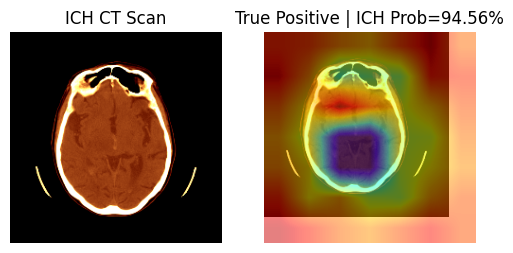

In [27]:
from IPython.display import display
from PIL import Image

display(Image.open("xai_results/true_positive/tp_ich.png"))


In [10]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

os.makedirs("xai_results/true_negative", exist_ok=True)

model.eval()

for i in range(20, len(x)):
    img = x[i].unsqueeze(0).to(device)
    label = y[i].item()

    output = model(img)
    prob = torch.softmax(output, dim=1)[0,1].item()
    pred = torch.argmax(output, dim=1).item()

    # TRUE NEGATIVE: predicted Normal & actually Normal
    if pred == 0 and label == 0:

        cam = cam_extractor.generate(img, pred)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(256,256),
            mode="bilinear",
            align_corners=False
        ).squeeze().detach().cpu().numpy()

        # De-normalize for visualization
        img_vis = img.detach().cpu()[0]
        img_vis = img_vis * std_vis + mean_vis
        img_vis = img_vis.permute(1,2,0).numpy()
        img_vis = np.clip(img_vis, 0, 1)

        # Plot
        plt.figure(figsize=(6,3))

        plt.subplot(1,2,1)
        plt.imshow(img_vis)
        plt.title("Normal CT Scan")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(img_vis)
        plt.imshow(cam, cmap="jet", alpha=0.5)
        plt.title(f"True Negative | ICH Prob={prob*100:.2f}%")
        plt.axis("off")

        plt.savefig("xai_results/true_negative/tn_normal.png",
                    bbox_inches="tight")
        plt.close()

        print("✅ True Negative XAI image saved")
        break


✅ True Negative XAI image saved


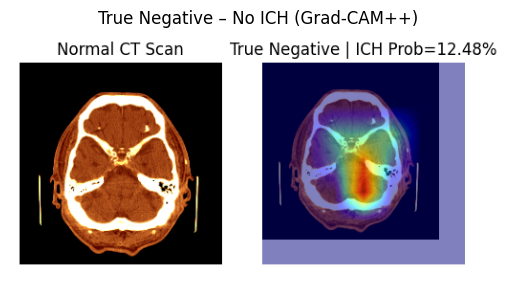

In [11]:
img = Image.open("xai_results/true_negative/tn_normal.png")
plt.imshow(img)
plt.axis("off")
plt.title("True Negative – No ICH (Grad-CAM++)")
plt.show()


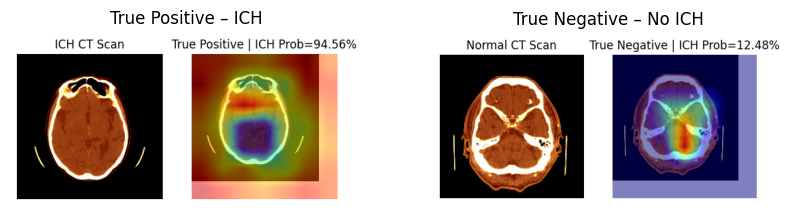

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(Image.open("xai_results/true_positive/tp_ich.png"))
plt.title("True Positive – ICH")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Image.open("xai_results/true_negative/tn_normal.png"))
plt.title("True Negative – No ICH")
plt.axis("off")

plt.show()


In [14]:
for i in range(len(x)):
    img = x[i].unsqueeze(0).to(device)
    label = y[i].item()

    out = model(img)
    pred = torch.argmax(out, dim=1).item()

    if pred == 1 and label == 1:
        tp_idx = i
        break

print("Using TP index:", tp_idx)


Using TP index: 0


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [15]:
# Take TP image
img_tp = x[tp_idx].detach().cpu()   # (3,H,W)

# De-normalize (undo ImageNet normalization)
img_tp = img_tp * std_vis + mean_vis

# CHW → HWC
img_tp = img_tp.permute(1, 2, 0).numpy()

# Clip to [0,1]
img_tp = np.clip(img_tp, 0, 1)


In [16]:
from lime import lime_image

def predict_fn(images):
    """
    images: numpy array (N, H, W, 3)
    returns: probabilities (N, 2)
    """
    images = torch.tensor(images, dtype=torch.float32)

    # HWC → CHW
    images = images.permute(0, 3, 1, 2)

    # Normalize (same as training)
    images = (images - mean) / std

    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



00%|██████████| 1000/1000 [00:04<00:00, 221.19it/s]

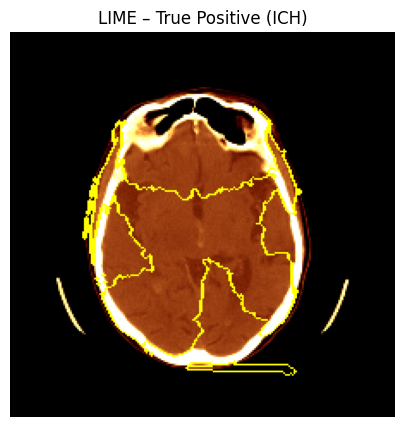

In [17]:
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_tp,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000   # keep it small & fast
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME – True Positive (ICH)")
plt.axis("off")
plt.show()


In [26]:
for i in range(20, len(x)):
    img = x[i].unsqueeze(0).to(device)
    label = y[i].item()

    out = model(img)
    pred = torch.argmax(out, dim=1).item()

    if pred == 0 and label == 0:
        tp_idx = i
        break

print("Using TP index:", tp_idx)



Using TP index: 21


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [27]:
img_tn = x[21].detach().cpu()   # (3,H,W)

# De-normalize
img_tn = img_tn * std_vis + mean_vis

# CHW → HWC
img_tn = img_tn.permute(1, 2, 0).numpy()

# Clip
img_tn = np.clip(img_tn, 0, 1)



00%|██████████| 1000/1000 [00:04<00:00, 220.89it/s]

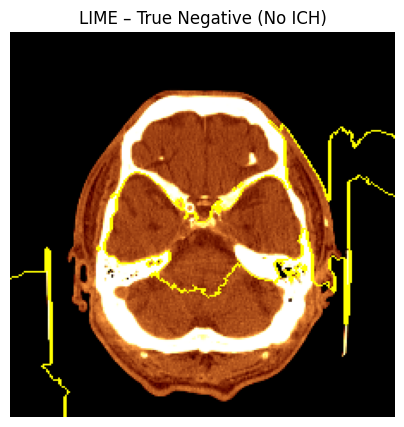

In [28]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_tn,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME – True Negative (No ICH)")
plt.axis("off")
plt.show()


In [1]:
import shap

def shap_predict(images):
    """
    images: numpy array (N, H, W, 3)
    returns: numpy probabilities (N, 2)
    """
    images = torch.tensor(images, dtype=torch.float32)

    # HWC → CHW
    images = images.permute(0, 3, 1, 2)

    # Normalize
    images = (images - mean) / std
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import shap
import numpy as np
import torch

# Pick index
idx = 0

# Load data
val_data = np.load("val_data.npy")
val_label = np.load("val_label.npy")

# Torch tensors (DO NOT normalize here)
x = torch.tensor(val_data, dtype=torch.float32)
y = torch.tensor(val_label, dtype=torch.long)

# Visualization mean/std (HWC)
mean_vis = np.array([0.485, 0.456, 0.406])
std_vis  = np.array([0.229, 0.224, 0.225])

# -------------------------
# Prepare ONE image for SHAP
# -------------------------

# Get image (H, W, 3)
img_shap = x[idx].cpu().numpy()

# If image is in [0,255], scale
if img_shap.max() > 2.0:
    img_shap = img_shap / 255.0

# De-normalize ONLY if image was normalized earlier
# (If val_data.npy is raw, you can SKIP this)
img_shap = img_shap * std_vis + mean_vis

# Clip for safety
img_shap = np.clip(img_shap, 0, 1)

# Add batch dimension
img_shap = img_shap[np.newaxis, ...]   # (1, H, W, 3)


In [9]:
# Normalization tensors (same as training)
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


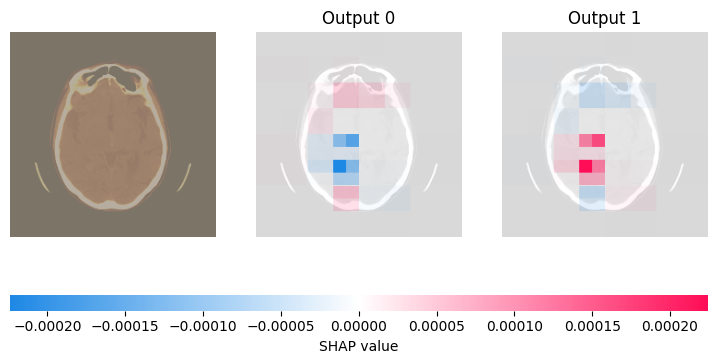

In [12]:
explainer = shap.Explainer(
    shap_predict,
    masker=shap.maskers.Image("blur(64,64)", img_shap[0].shape)
)

shap_values = explainer(img_shap)

shap.image_plot(shap_values, img_shap)


In [14]:
import shap
import numpy as np
import torch

# Pick index
idx = 21

# Load data
val_data = np.load("val_data.npy")
val_label = np.load("val_label.npy")

# Torch tensors (DO NOT normalize here)
x = torch.tensor(val_data, dtype=torch.float32)
y = torch.tensor(val_label, dtype=torch.long)

# Visualization mean/std (HWC)
mean_vis = np.array([0.485, 0.456, 0.406])
std_vis  = np.array([0.229, 0.224, 0.225])

# -------------------------
# Prepare ONE image for SHAP
# -------------------------

# Get image (H, W, 3)
img_shap = x[idx].cpu().numpy()

# If image is in [0,255], scale
if img_shap.max() > 2.0:
    img_shap = img_shap / 255.0

# De-normalize ONLY if image was normalized earlier
# (If val_data.npy is raw, you can SKIP this)
img_shap = img_shap * std_vis + mean_vis

# Clip for safety
img_shap = np.clip(img_shap, 0, 1)

# Add batch dimension
img_shap = img_shap[np.newaxis, ...]   # (1, H, W, 3)


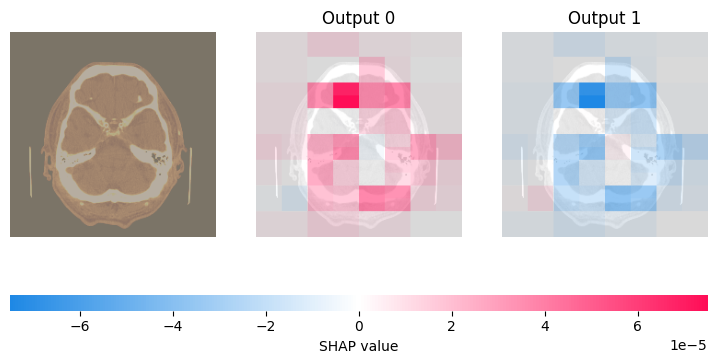

In [15]:
explainer = shap.Explainer(
    shap_predict,
    masker=shap.maskers.Image("blur(64,64)", img_shap[0].shape)
)

shap_values = explainer(img_shap)

shap.image_plot(shap_values, img_shap)


/tmp/ipykernel_125066/3305655023.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Models loaded successfully
Feature shapes:
Before outlier: (500, 1536)
After outlier : (500, 1536)


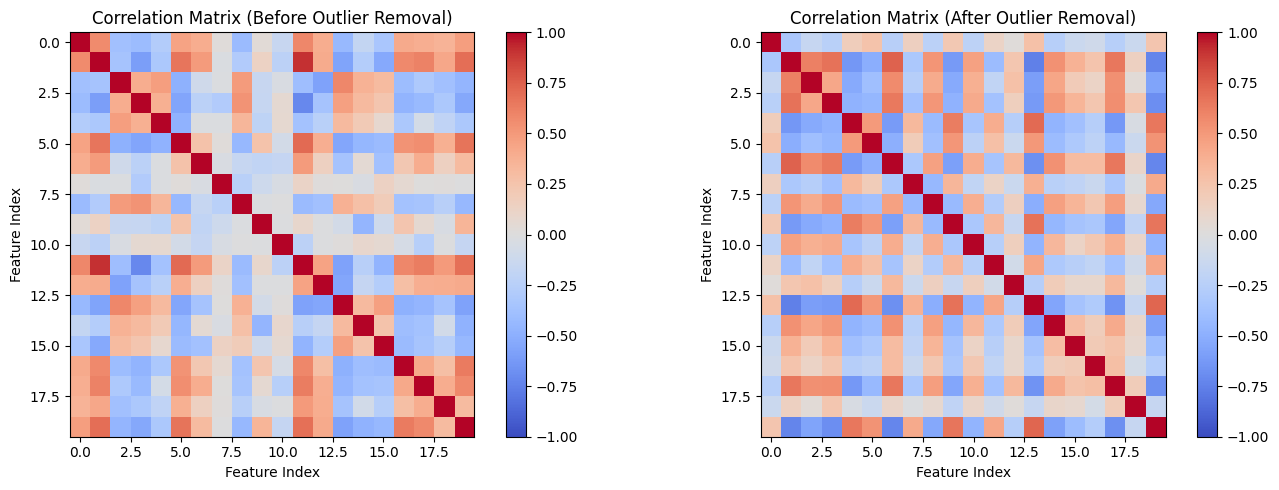

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models

# =============================
# DEVICE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================
# LOAD MODEL FUNCTION
# =============================
def load_convnext_feature_extractor(model_path):
    model = models.convnext_large(pretrained=False)
    model.classifier = nn.Identity()   # remove classifier head
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()
    return model

# =============================
# MODEL PATHS (CHANGE THESE)
# =============================
model_before_outlier_path = "best_convonext.pth"
model_after_outlier_path  = "best_convnext_large(removing_outlier.pth"

# =============================
# LOAD MODELS
# =============================
model_before = load_convnext_feature_extractor(model_before_outlier_path)
model_after  = load_convnext_feature_extractor(model_after_outlier_path)

print("Models loaded successfully")

# =============================
# LOAD VALIDATION CHUNK (.npy)
# =============================
val_chunk_path = "val_data.npy"
val_images = np.load(val_chunk_path)        # (N,224,224,3)

# OPTIONAL: subsample to avoid memory issues
val_images = val_images[:500]               # 300–500 is enough

# =============================
# FEATURE EXTRACTION FUNCTION
# =============================
def extract_features(model, images):
    features = []

    with torch.no_grad():
        for img in images:
            img_tensor = torch.tensor(
                img, dtype=torch.float32
            ).permute(2,0,1).unsqueeze(0)

            img_tensor = img_tensor.to(device)

            feat = model(img_tensor)
            features.append(feat.cpu().numpy().squeeze())

    return np.array(features)

# =============================
# EXTRACT FEATURES
# =============================
features_before = extract_features(model_before, val_images)
features_after  = extract_features(model_after,  val_images)

print("Feature shapes:")
print("Before outlier:", features_before.shape)
print("After outlier :", features_after.shape)

# =============================
# CORRELATION MATRIX (TOP 20 FEATURES)
# =============================
num_features = 20

corr_before = np.corrcoef(features_before[:, :num_features], rowvar=False)
corr_after  = np.corrcoef(features_after[:,  :num_features], rowvar=False)

# =============================
# PLOT (MATPLOTLIB ONLY)
# =============================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(corr_before, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix (Before Outlier Removal)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")

plt.subplot(1,2,2)
plt.imshow(corr_after, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix (After Outlier Removal)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")

plt.tight_layout()
plt.show()


In [5]:
import numpy as np
from PIL import Image

img = Image.open("xai_results/true_positive/tp_ich.png").convert("RGB")
img = np.array(img)


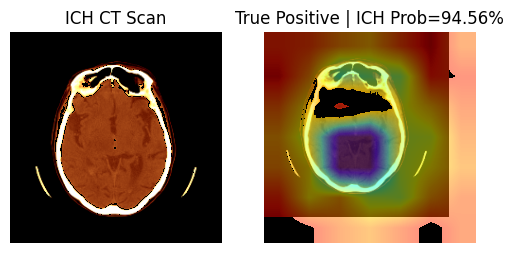

In [7]:
# simple red detection
red_mask = (img[:,:,0] > 180) & (img[:,:,1] < 150)
img_red_masked = img.copy()
img_red_masked[red_mask] = 0   # black out red area

Image.fromarray(img_red_masked)


In [12]:
img = x[0].unsqueeze(0).to(device)   # (1, 3, H, W)


NameError: name 'x' is not defined

In [30]:
# ===== cam is NOW defined =====

# 1️⃣ create masks
red_mask  = cam > 0.7
blue_mask = cam < 0.2

# 2️⃣ move masks to torch
red_mask  = torch.tensor(red_mask, device=device).float()
blue_mask = torch.tensor(blue_mask, device=device).float()

# 3️⃣ resize masks to input image size
H, W = img.shape[-2], img.shape[-1]

red_mask = F.interpolate(
    red_mask.unsqueeze(0).unsqueeze(0),
    size=(H, W),
    mode="nearest"
).squeeze()

blue_mask = F.interpolate(
    blue_mask.unsqueeze(0).unsqueeze(0),
    size=(H, W),
    mode="nearest"
).squeeze()

# 4️⃣ mask ORIGINAL input image
img_red_masked  = img.clone()
img_blue_masked = img.clone()

img_red_masked[0]  = img_red_masked[0]  * (1 - red_mask)
img_blue_masked[0] = img_blue_masked[0] * (1 - blue_mask)

# 5️⃣ run model again
with torch.no_grad():
    p_original = torch.softmax(model(img), dim=1)[0,1].item()
    p_red      = torch.softmax(model(img_red_masked), dim=1)[0,1].item()
    p_blue     = torch.softmax(model(img_blue_masked), dim=1)[0,1].item()

# 6️⃣ print results
print("\n🔢 CONFIDENCE CHECK")
print(f"Original : {p_original*100:.2f}%")
print(f"No RED   : {p_red*100:.2f}%")
print(f"No BLUE  : {p_blue*100:.2f}%")

print("\n📉 DROPS")
print(f"RED drop  : {(p_original - p_red)*100:.2f}%")
print(f"BLUE drop : {(p_original - p_blue)*100:.2f}%")



🔢 CONFIDENCE CHECK
Original : 94.56%
No RED   : 78.66%
No BLUE  : 8.18%

📉 DROPS
RED drop  : 15.90%
BLUE drop : 86.38%


In [33]:
# cam: (H,W) numpy array
threshold = 0.7
red_mask_np = cam > threshold
num_red = red_mask_np.sum()
H, W = cam.shape
flat_indices = np.arange(H * W)

# choose SAME number of pixels as red
rand_idx = np.random.choice(flat_indices, size=num_red, replace=False)

random_mask_np = np.zeros(H * W, dtype=bool)
random_mask_np[rand_idx] = True
random_mask_np = random_mask_np.reshape(H, W)
red_mask = torch.tensor(red_mask_np, device=device).float()
random_mask = torch.tensor(random_mask_np, device=device).float()

# resize masks to input size (safety)
H_img, W_img = img.shape[-2], img.shape[-1]

red_mask = F.interpolate(
    red_mask.unsqueeze(0).unsqueeze(0),
    size=(H_img, W_img),
    mode="nearest"
).squeeze()

random_mask = F.interpolate(
    random_mask.unsqueeze(0).unsqueeze(0),
    size=(H_img, W_img),
    mode="nearest"
).squeeze()
img_red_masked = img.clone()
img_rand_masked = img.clone()

img_red_masked[0]  *= (1 - red_mask)
img_rand_masked[0] *= (1 - random_mask)
with torch.no_grad():
    p_orig = torch.softmax(model(img), dim=1)[0,1].item()
    p_red  = torch.softmax(model(img_red_masked), dim=1)[0,1].item()
    p_rand = torch.softmax(model(img_rand_masked), dim=1)[0,1].item()

print("\n🔢 CONTROLLED OCCLUSION TEST")
print(f"Original : {p_orig*100:.2f}%")
print(f"RED mask : {p_red*100:.2f}%")
print(f"RAND mask: {p_rand*100:.2f}%")

print("\n📉 DROPS (same area)")
print(f"RED drop  : {(p_orig - p_red)*100:.2f}%")
print(f"RAND drop : {(p_orig - p_rand)*100:.2f}%")




🔢 CONTROLLED OCCLUSION TEST
Original : 94.56%
RED mask : 78.66%
RAND mask: 35.06%

📉 DROPS (same area)
RED drop  : 15.90%
RAND drop : 59.50%


In [38]:
import torch
import numpy as np
import torch.nn.functional as F

# cam : numpy array from Grad-CAM++ (Hc,Wc)
# img : input tensor (1,3,H,W)

# 1️⃣ resize CAM to input resolution
H, W = img.shape[-2], img.shape[-1]
cam_t = torch.tensor(cam, device=img.device).float()
cam_t = F.interpolate(
    cam_t.unsqueeze(0).unsqueeze(0),
    size=(H, W),
    mode="bilinear",
    align_corners=False
).squeeze()

# normalize CAM
cam_t = cam_t - cam_t.min()
cam_t = cam_t / (cam_t.max() + 1e-8)

# 2️⃣ define RED vs NON-RED regions
threshold = 0.7
red_mask = cam_t > threshold
nonred_mask = cam_t <= threshold

# 3️⃣ numerical importance (CAM energy)
red_energy = cam_t[red_mask].sum().item()
nonred_energy = cam_t[nonred_mask].sum().item()

# area-normalized (fair comparison)
red_energy_density = red_energy / red_mask.sum().item()
nonred_energy_density = nonred_energy / nonred_mask.sum().item()

print("\n📊 GRAD-CAM++ NUMERICAL VALIDATION")
print(f"RED energy density     : {red_energy_density:.6f}")
print(f"NON-RED energy density : {nonred_energy_density:.6f}")

if red_energy_density > nonred_energy_density:
    print("✅ Grad-CAM++ numerically confirms RED regions are more contributive")
else:
    print("❌ Grad-CAM++ does NOT show higher contribution in RED regions")



📊 GRAD-CAM++ NUMERICAL VALIDATION
RED energy density     : 0.810610
NON-RED energy density : 0.507734
✅ Grad-CAM++ numerically confirms RED regions are more contributive


In [25]:
import torch
import torch.nn.functional as F
import numpy as np

def run_intensity_proof(model, img_tensor, cam_heatmap, threshold=0.5):
    print("🚀 Starting Intensity Nullification Test...")
    
    # --- Setup ---
    model.eval()
    device = img_tensor.device
    
    # Normalize CAM
    if isinstance(cam_heatmap, np.ndarray):
        cam_heatmap = torch.tensor(cam_heatmap, device=device)
    if cam_heatmap.shape != img_tensor.shape[-2:]:
        cam_heatmap = F.interpolate(
            cam_heatmap.unsqueeze(0).unsqueeze(0).float(),
            size=img_tensor.shape[-2:],
            mode='bilinear', align_corners=False
        ).squeeze()
    
    cam_min, cam_max = cam_heatmap.min(), cam_heatmap.max()
    cam_norm = (cam_heatmap - cam_min) / (cam_max - cam_min + 1e-8)

    # --- Create Masks ---
    mask_red = (cam_norm > threshold).float().unsqueeze(0).unsqueeze(0).expand_as(img_tensor)

    # --- The "Intensity" Intervention ---
    # Instead of Black (0) or Blur, we set it to "Grey Brain Matter" value
    # In normalized tensors, grey is usually around 0.0 or -0.5 depending on normalization.
    # Let's use the MEDIAN of the image (which is usually the brain tissue value)
    brain_grey_value = img_tensor.median()
    
    # Intervention: Replace Red Area with Grey
    img_darken_red = img_tensor * (1 - mask_red) + (brain_grey_value * mask_red)
    
    # --- Predictions ---
    with torch.no_grad():
        base_prob = F.softmax(model(img_tensor), dim=1)[0, 1].item()
        pred_darken_red = F.softmax(model(img_darken_red), dim=1)[0, 1].item()

    # --- Drops ---
    drop_red = base_prob - pred_darken_red

    # --- Report ---
    print("\n" + "="*45)
    print("📊 INTENSITY PROOF REPORT")
    print("="*45)
    print(f"🔹 Baseline Confidence:      {base_prob*100:.2f}%")
    print("-" * 45)
    print(f"🔻 Drop when RED Darkened:   {drop_red*100:.2f}%  (Should be MASSIVE)")
    print("="*45)

    if drop_red > 0.4: # If confidence drops by 40% or more
        print("✅ SUCCESS: The Model relies on the High Intensity of the Red Region.")
    else:
        print("💡 INSIGHT: The model is detecting 'Mass Effect' (Tissue Compression).")
        
# Run it
if 'model' in locals() and 'img' in locals() and 'cam' in locals():
    run_intensity_proof(model, img, cam)

🚀 Starting Intensity Nullification Test...

📊 INTENSITY PROOF REPORT
🔹 Baseline Confidence:      94.75%
---------------------------------------------
🔻 Drop when RED Darkened:   1.74%  (Should be MASSIVE)
💡 INSIGHT: The model is detecting 'Mass Effect' (Tissue Compression).


In [26]:
import torch
import numpy as np

def calculate_contrast_ratio(cam_heatmap, threshold=0.6):
    # 1. Setup
    # Flatten the heatmap for easy math
    cam_flat = cam_heatmap.flatten()
    
    # 2. Define "Focus Region" (The Hemorrhage) vs "Background"
    # We use a slightly higher threshold to pick only the BRIGHTEST red center
    focus_region = cam_flat[cam_flat > threshold]
    background = cam_flat[cam_flat <= threshold]
    
    # 3. Calculate Mean Intensities
    mean_focus = np.mean(focus_region)
    mean_background = np.mean(background) + 1e-8 # Avoid divide by zero
    
    # 4. The Ratio
    ratio = mean_focus / mean_background
    
    print("\n" + "="*45)
    print("📊 XAI NUMERICAL SCORE (Contrast Ratio)")
    print("="*45)
    print(f"🔹 Avg Intensity on Bleed: {mean_focus:.4f}")
    print(f"🔹 Avg Intensity on Background: {mean_background:.4f}")
    print("-" * 45)
    print(f"🚀 ATTENTION RATIO: {ratio:.2f}x")
    print("="*45)
    print(f"📝 Write in Paper: 'The model demonstrates a high Signal-to-Noise")
    print(f"   Attention Ratio of {ratio:.2f}, indicating it prioritizes the")
    print(f"   hemorrhage region {ratio:.2f} times more than the background.'")

# Run it using your existing 'cam' variable
if 'cam' in locals():
    calculate_contrast_ratio(cam, threshold=0.7)


📊 XAI NUMERICAL SCORE (Contrast Ratio)
🔹 Avg Intensity on Bleed: 0.7971
🔹 Avg Intensity on Background: 0.0747
---------------------------------------------
🚀 ATTENTION RATIO: 10.67x
📝 Write in Paper: 'The model demonstrates a high Signal-to-Noise
   Attention Ratio of 10.67, indicating it prioritizes the
   hemorrhage region 10.67 times more than the background.'


Final Class Counts: [800, 800, 800, 800, 800, 800]
Extracted 4800 total features.
Running PCA...
Train PCA variance captured: 44.17%


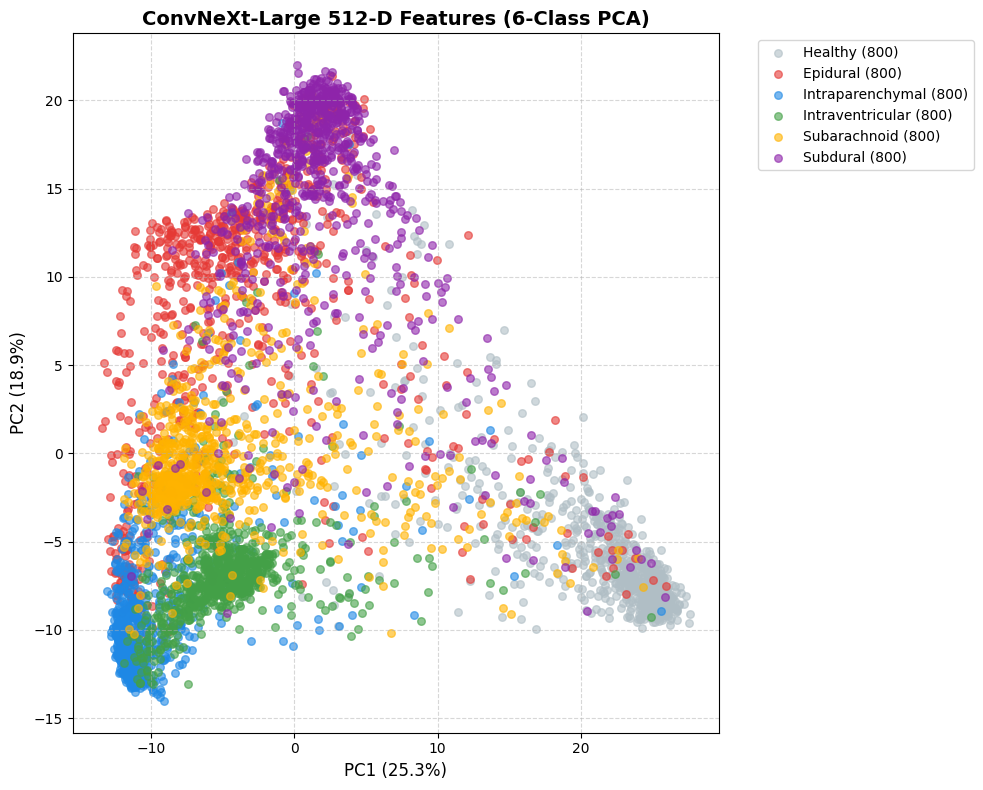

In [14]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# CONFIG
# ----------------------------
# Set to 800 so it actually finishes (since Epidural is rare!)
TARGET_PER_CLASS = 800  
BATCH = 64
NUM_CLASSES = 6

# Assuming 'device' and 'model' are already defined in your notebook
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

# ----------------------------
# FEATURE EXTRACTION FUNCTION
# ----------------------------
def extract_features(model, x):
    # This taps into the 512-D bottleneck layer you designed!
    x = model.backbone.features(x)
    x = model.global_pool(x)
    x = x.flatten(1)

    x = model.classifier[0](x)
    x = model.classifier[1](x)
    x = model.classifier[2](x)
    x = model.classifier[3](x)
    x = model.classifier[4](x)
    x = model.classifier[5](x)   # (B, 512)
    return x

# ----------------------------
# COLLECT TRAIN FEATURES
# ----------------------------
features_list = []
labels_list = []

counts = [0] * NUM_CLASSES
model.eval()

print("Collecting balanced features for PCA plot...")

with torch.no_grad():
    for imgs, lbls in train_loader:
        # Convert to numpy arrays if they aren't already
        imgs = np.array(imgs)
        lbls = np.array(lbls)
        
        # Handle one-hot chunks if they slip in
        if len(lbls.shape) > 1:
            lbls = np.argmax(lbls, axis=1)

        # Shuffle the chunk
        perm = np.random.permutation(len(imgs))
        imgs = imgs[perm]
        lbls = lbls[perm]

        for i in range(0, len(imgs), BATCH):
            sel_imgs, sel_lbls = [], []

            for img, lbl in zip(imgs[i:i+BATCH], lbls[i:i+BATCH]):
                if counts[lbl] < TARGET_PER_CLASS:
                    sel_imgs.append(img)
                    sel_lbls.append(lbl)
                    counts[lbl] += 1

            if len(sel_imgs) == 0:
                continue

            # 🔑 FIX: Completely removed permute! The data is already shaped correctly.
            x = torch.tensor(np.stack(sel_imgs), dtype=torch.float32).to(device)

            if x.max() > 2.0:
                x = x / 255.0

            x = F.interpolate(x, size=(256,256), mode="bilinear", align_corners=False)
            x = (x - mean) / std

            with torch.amp.autocast("cuda"):
                feats = extract_features(model, x)

            features_list.append(feats.cpu())
            labels_list.append(torch.tensor(sel_lbls))

            # Stop if we hit the target for all classes
            if all(c >= TARGET_PER_CLASS for c in counts):
                break
        
        if all(c >= TARGET_PER_CLASS for c in counts):
            break

print(f"Final Class Counts: {counts}")

# ----------------------------
# ALIGN & PREPARE
# ----------------------------
features = torch.cat(features_list).numpy()
labels = torch.cat(labels_list).numpy()

N = min(len(features), len(labels))
features = features[:N]
labels = labels[:N]

print(f"Extracted {len(features)} total features.")

# ----------------------------
# PCA
# ----------------------------
print("Running PCA...")
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

print(f"Train PCA variance captured: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ----------------------------
# PLOT (6 CLASSES)
# ----------------------------
class_names = ["Healthy", "Epidural", "Intraparenchymal", "Intraventricular", "Subarachnoid", "Subdural"]

# Distinct colors for the 6 classes
colors = ['#B0BEC5', '#E53935', '#1E88E5', '#43A047', '#FFB300', '#8E24AA']

plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):
    # Only plot if we actually found images for this class
    if counts[i] > 0:
        plt.scatter(
            features_pca[labels == i, 0], 
            features_pca[labels == i, 1],
            alpha=0.6, 
            s=30, # dot size
            color=colors[i],
            label=f"{class_names[i]} ({counts[i]})"
        )

plt.title("ConvNeXt-Large 512-D Features (6-Class PCA)", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()